### Data Analysis Process

![Data Analysis Process](https://github.com/Data-Analytics-Tutors/0-Introduction/blob/master/images/Intro%20to%20Data%20Analytics%20Case%20Study.png?raw=1)


### Data Understanding

Data sourced from Dallas Open Data Portal, [Vendor Payments for Fiscal Year 2019-Present](https://www.dallasopendata.com/Economy/Vendor-Payments-for-Fiscal-Year-2019-Present/x5ih-idh7)
Latest 500k query.
Resources:
- Questions sourced from [Dallas Open Records](https://dallastx.govqa.us/WEBAPP/_rs/(S(yvwdnfffcg5vrmly43gmvfag))/OpenRecordsSummary.aspx?sSessionID=)

The csv  has 22 columns and 850,000+ rows.
Features include:
(List of columns)


## FIELD NAME DESCRIPTION
-   RUN DATE DATE POSTED
-   FY FISCAL YEAR
-   FM FISCAL MONTH ‐ OCTOBER IS MONTH 1/SEPTEMBER IS MONTH 12/PERIOD 13 IS AN ADJUSTMENT PERIOD AT YEAR END
-   DOC‐ID SYSTEM DOCUMENT ID ‐ READS AS FOLLOWS ‐ DOCUMENT TYPE‐DEPARTMENT‐DOCUMENT NUMBER
-   CHKSUBTOT PAYMENT SUBTOTAL BY LINE ITEM
-   VCODE VENDOR CODE
-   VENDOR VENDOR NAME
-   ZIP5 VENDOR ZIP CODE
-   FTYP FUND TYPE ABBREVIATION ‐ SEE THE 'READ MORE' SECTION OF THIS WEBSITE FOR DESCRIPTIONS
-   FUND TYPE FUND TYPE ‐ SEE THE 'READ MORE' SECTION OF THIS WEBSITE FOR DESCRIPTIONS
-   DPT DEPARTMENT ABBREVIATION
-   DEPARTMENT DEPARTMENT
-   ACTV INTERNAL ACTIVITY CODE
-   ACTIVITY ACTIVITY
-   OGRP OBJECT GROUP ABBREVIATION
-   OBJECTGROUP OBJECT GROUP (SPECIFIES THE EXPENDITURE CLASSIFICATION)
-   OBJ NUMERIC CODE ASSOCIATED WITH THE OBJECT
-   OBJECT DESCRIPTION OF OBJ ‐ OBJECTS ARE PLACED IN TO OBJECT GROUPS FOR CLASSIFICATION, BASED ON THEIR OBJ CODE
-   COMM COMMODITY CODE
-   COMMODITY DSCR DESCRIPTION OF COMM (COMMODITY CODE)
-   INVOICEDATE NOT APPLICABLE
-   INVOICENUMBER NOT APPLICABLE

In [1]:
!pip install sidetable
import sidetable as stb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 476.6 kB/s eta 0:00:00


In [2]:
#Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import datetime
import numpy as np
import seaborn as sns
#from pandas_profiling import ProfileReport

In [3]:
#Read in data (could be done from a file(excel/csv), API, link, or SQL dB)
df = pd.read_csv("https://www.dallasopendata.com/resource/x5ih-idh7.csv?$limit=500000")
df.shape
#examine the shape of the data

(176441, 22)

In [4]:
#formatting columns, specifically the chksubtot column
format_dict =  {'chksubtot':'${:,.2f}'}

In [7]:
#returns the first 5 rows of data
#df.head(20)

#returns the last 5 rows of data
df.tail()

,rundate,fy,fm,docid,chksubtot,vcode,vendor,zip5,ftyp,fundtype,...,actv,activity,ogrp,objectgroup,obj,object,comm,commoditydscr,invoicedate,invoicenumber
176436,2022-10-03T00:00:00.000,2023,1,EFT-BMS-EY230000116,1154.40,VS0000066539,"SMITH TEMPORARIES, INC",75201,GNFD,General Fund,...,EH54,Comprehensive Homeless Outreach,QV,Contractual & Other Services,3994,Outside Temps/Staffing,96269.0,"PERSONNEL SERVICES, TEMPORARY",NaN,NaN
176437,2022-10-02T00:00:00.000,2023,1,AD-BMS-AY220029727,-4723.13,VC23892,Hargett Electric Co.,78756,FDGT,Federal Grant (non Consolidated Plan),...,EH99,"Supplemental Nutrition Program For Women, Infa...",QV,Contractual & Other Services,3330,Rents (Lease),97145.0,OFFICE SPACE RENTAL OR LEASE,NaN,NaN
176438,2022-10-02T00:00:00.000,2023,1,EFT-BMS-EY220046829,-606.75,VC0000007948,NEVADA TEXAS REAL ESTATE,75208,CNPL,Consolidated Plan Funds,...,EH27,Homeless Housing Services,QV,Contractual & Other Services,3350,Rents/Rental Assistance Pgm,NaN,NONE,NaN,NaN
176439,2022-10-02T00:00:00.000,2023,1,AD-BMS-AY220032235,-700.00,342510,BURDIN MEDIATIONS,75205,OTHO,Other Operating Fund,...,RM01,Risk Management Services,QV,Contractual & Other Services,3042,Mediation Fees,NaN,NONE,NaN,NaN
176440,2022-10-02T00:00:00.000,2023,1,AD-BMS-AY220025456,-1800.00,MVORM001,Shannell Jordan ANF Kimberly Lockett and Ben A...,NaN,OTHO,Other Operating Fund,...,RM01,Risk Management Services,QV,Contractual & Other Services,3521,Judgements & Damages,NaN,NONE,NaN,NaN


### Exploratory Data Analysis

In [8]:
df.dtypes

#examine the data data types

,0
rundate,object
fy,int64
fm,int64
docid,object
chksubtot,float64
vcode,object
vendor,object
zip5,object
ftyp,object
fundtype,object


In [9]:
df.info()
#examine the info for the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176441 entries, 0 to 176440
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   rundate        176441 non-null  object 
 1   fy             176441 non-null  int64  
 2   fm             176441 non-null  int64  
 3   docid          176441 non-null  object 
 4   chksubtot      176441 non-null  float64
 5   vcode          176441 non-null  object 
 6   vendor         176441 non-null  object 
 7   zip5           172726 non-null  object 
 8   ftyp           176441 non-null  object 
 9   fundtype       176441 non-null  object 
 10  dpt            176441 non-null  object 
 11  department     176441 non-null  object 
 12  actv           176441 non-null  object 
 13  activity       176441 non-null  object 
 14  ogrp           176441 non-null  object 
 15  objectgroup    176441 non-null  object 
 16  obj            176441 non-null  object 
 17  object         176441 non-nul

In [10]:
df.describe()
#describe the data

,fy,fm,chksubtot,comm,invoicedate,invoicenumber
count,176441.000000,176441.000000,1.764410e+05,150529.000000,0.0,0.0
mean,2023.487965,5.653601,1.815930e+04,68978.794571,NaN,NaN
std,0.499857,3.380153,1.693269e+05,34914.194320,NaN,NaN
min,2023.000000,1.000000,-5.989183e+05,500.000000,NaN,NaN
25%,2023.000000,3.000000,2.477000e+02,40513.000000,NaN,NaN
50%,2023.000000,5.000000,9.495000e+02,91200.000000,NaN,NaN
75%,2024.000000,8.000000,4.048320e+03,96221.000000,NaN,NaN
max,2024.000000,12.000000,2.817387e+07,99277.000000,NaN,NaN


from matplotlib import pyplot as plt
_df_0['fy'].plot(kind='hist', bins=20, title='fy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['fm'].plot(kind='hist', bins=20, title='fm')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['chksubtot'].plot(kind='hist', bins=20, title='chksubtot')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['comm'].plot(kind='hist', bins=20, title='comm')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='fm', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='chksubtot', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='comm', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [11]:
df.department.value_counts()
# here we are looking at the number of times a dept is represented

,count
department,
Water Utilities,34499
Inventory Purchase,19962
Management Services,17695
Park & Recreation,17501
Aviation,8484
Equipment & Fleet Management,7754
Dallas Police Dept,7672
Public Works & Transporation,6418
Sanitation Svcs,5758


In [12]:
#number  of null values
df.isnull().sum()

#percentage of null values
#df.isnull().mean()



,0
rundate,0
fy,0
fm,0
docid,0
chksubtot,0
vcode,0
vendor,0
zip5,3715
ftyp,0
fundtype,0


In [ ]:
df['department'] = df.department.astype('string')
df.department.dtypes

#### Which department has the most vendor payouts  and what is its average payout amount?

In [13]:
format_dict = {'chksubtot':'${:,.0f}'}


In [14]:
#fy 2024
fy_24 = df[df.fy ==2024]
fy_24.style.format(format_dict)
fy_24.stb.freq(['department'], value='chksubtot', style=True, cum_cols=False)

,department,chksubtot,percent
0,Water Utilities,"486,683,236",30.93%
1,Public Works & Transporation,"155,803,383",9.90%
2,Communication & Info Svcs,"105,803,205",6.72%
3,Aviation,"82,403,807",5.24%
4,Park & Recreation,"81,223,668",5.16%
5,Management Services,"77,879,215",4.95%
6,Convention And Event Services,"67,662,707",4.30%
7,Office Of Economic Development,"52,173,084",3.32%
8,Inventory Purchase,"51,233,255",3.26%
9,Dallas Police Dept,"45,339,342",2.88%


#### Question 2 : AVI Vendors
##### Which vendor recieved the most overall pay out from the aviation department?



In [15]:
avi_dept = df[df.department =='Aviation']
avi_dept.style.format(format_dict)
avi_dept.head()

,rundate,fy,fm,docid,chksubtot,vcode,vendor,zip5,ftyp,fundtype,...,actv,activity,ogrp,objectgroup,obj,object,comm,commoditydscr,invoicedate,invoicenumber
44,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061708,400.00,VC23279,Zuriel Bertch,76134,EFOP,Enterprise Operating Fund,...,AV31,AIRPORT COMMUNICATION CENTER,QV,Contractual & Other Services,3070,Professional Services,96205.0,AMUSEMENT AND ENTERTAINMENT SERVICES (INCL. PE...,NaN,NaN
47,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061652,15614.88,399295,ATMOS ENERGY CORPORATION,45274,EFOP,Enterprise Operating Fund,...,AV20,UTILITIES,QM,Supplies & Materials,2160,Fuel Supplies,96185.0,"UTILITY SERVICES, ELECTRIC, GAS, WATER",NaN,NaN
66,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061730,1151.00,VC28509,"Marco Holdings I, LLC",76031,EFOP,Enterprise Operating Fund,...,AV14,DAL PAVEMENT,QM,Supplies & Materials,2182,Mechanical Supplies Veh,7500.0,AUTOMOTIVE SHOP EQUIPMENT AND SUPPLIES,NaN,NaN
84,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061661,60.00,512715,PETALS & STEMS FLORIST,75240,EFOP,Enterprise Operating Fund,...,AV31,AIRPORT COMMUNICATION CENTER,QV,Contractual & Other Services,3899,Other Misc.Exp. & Reimbursement,59528.0,"FLOWERS, FRESH",NaN,NaN
97,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061786,841.63,VS100479,Holt Construction Corporation,10965,AVIC,Aviation Capital Program,...,AAIP,Airport Improvements,RC,Capital Outlay,4599,Other Improvements-other than Building,NaN,NONE,NaN,NaN


In [ ]:
avi_dept = df[df.department =='Civil Service']
avi_dept.style.format(format_dict)
avi_dept.head()

In [16]:
avi_dept.shape

(8484, 22)

In [17]:
#first, lets isolate the Aviation dept, vendors from the rest the data
aviation_vendors_sum = avi_dept.groupby(['vendor'])['chksubtot'].agg(['sum']).sort_values(by=['sum'],ascending=False)
aviation_vendors_sum

,sum
vendor,
"Flatiron Constructors, Inc.",53369805.23
"RoeschCo Construction, LLC",8321547.37
HNTB CORPORATION,7174644.12
"DLF Denton, LLC",6651047.53
"Member's Building Maintenance, LLC.",6105647.96
...,...
Sheena Swehla,28.98
THOMAS REPROGRAPHICS INC,24.00
Patrick Weatherspoon,4.13


In [18]:
#contains_clear, searching for vendor payout to "Flatiron Contractors"
avi_dept.loc[avi_dept['vendor'].str.contains('Flatiron', case=False)]

,rundate,fy,fm,docid,chksubtot,vcode,vendor,zip5,ftyp,fundtype,...,actv,activity,ogrp,objectgroup,obj,object,comm,commoditydscr,invoicedate,invoicenumber
3435,2024-07-19T00:00:00.000,2024,10,EFT-BMS-EY240059624,1574372.18,VS96112,"Flatiron Constructors, Inc.",75038,AVRC,Aviation Capital Program.commercial paper,...,AAIP,Airport Improvements,RC,Capital Outlay,4599,Other Improvements-other than Building,92500.0,"ENGINEERING SERVICES, PROFESSIONAL",NaN,NaN
10956,2024-06-18T00:00:00.000,2024,9,EFT-BMS-EY240054768,453431.98,VS96112,"Flatiron Constructors, Inc.",75038,AVRC,Aviation Capital Program.commercial paper,...,AAIP,Airport Improvements,RC,Capital Outlay,4599,Other Improvements-other than Building,92500.0,"ENGINEERING SERVICES, PROFESSIONAL",NaN,NaN
12172,2024-06-12T00:00:00.000,2024,9,EFT-BMS-EY240053874,1244230.00,VS96112,"Flatiron Constructors, Inc.",75038,FDGT,Federal Grant (non Consolidated Plan),...,PVMT,Pavement Maintenance / Construction,RC,Capital Outlay,4599,Other Improvements-other than Building,92500.0,"ENGINEERING SERVICES, PROFESSIONAL",NaN,NaN
12282,2024-06-12T00:00:00.000,2024,9,EFT-BMS-EY240053874,414743.33,VS96112,"Flatiron Constructors, Inc.",75038,AVIC,Aviation Capital Program,...,PVMT,Pavement Maintenance / Construction,RC,Capital Outlay,4599,Other Improvements-other than Building,92500.0,"ENGINEERING SERVICES, PROFESSIONAL",NaN,NaN
12392,2024-06-12T00:00:00.000,2024,9,EFT-BMS-EY240053874,2370430.12,VS96112,"Flatiron Constructors, Inc.",75038,AVRC,Aviation Capital Program.commercial paper,...,AAIP,Airport Improvements,RC,Capital Outlay,4599,Other Improvements-other than Building,92500.0,"ENGINEERING SERVICES, PROFESSIONAL",NaN,NaN
15217,2024-05-30T00:00:00.000,2024,8,EFT-BMS-EY240051956,379102.35,VS96112,"Flatiron Constructors, Inc.",75038,AVIC,Aviation Capital Program,...,PVMT,Pavement Maintenance / Construction,RC,Capital Outlay,4599,Other Improvements-other than Building,92500.0,"ENGINEERING SERVICES, PROFESSIONAL",NaN,NaN
15303,2024-05-30T00:00:00.000,2024,8,EFT-BMS-EY240051956,1137307.08,VS96112,"Flatiron Constructors, Inc.",75038,FDGT,Federal Grant (non Consolidated Plan),...,PVMT,Pavement Maintenance / Construction,RC,Capital Outlay,4599,Other Improvements-other than Building,92500.0,"ENGINEERING SERVICES, PROFESSIONAL",NaN,NaN
15697,2024-05-28T00:00:00.000,2024,8,EFT-BMS-EY240051537,115155.66,VS96112,"Flatiron Constructors, Inc.",75038,AVRC,Aviation Capital Program.commercial paper,...,AAIP,Airport Improvements,RC,Capital Outlay,4599,Other Improvements-other than Building,92500.0,"ENGINEERING SERVICES, PROFESSIONAL",NaN,NaN
16779,2024-05-22T00:00:00.000,2024,8,EFT-BMS-EY240050844,376841.64,VS96112,"Flatiron Constructors, Inc.",75038,AVIC,Aviation Capital Program,...,PVMT,Pavement Maintenance / Construction,RC,Capital Outlay,4599,Other Improvements-other than Building,92500.0,"ENGINEERING SERVICES, PROFESSIONAL",NaN,NaN
16827,2024-05-22T00:00:00.000,2024,8,EFT-BMS-EY240050844,162050.32,VS96112,"Flatiron Constructors, Inc.",75038,FDGT,Federal Grant (non Consolidated Plan),...,PVMT,Pavement Maintenance / Construction,RC,Capital Outlay,4599,Other Improvements-other than Building,92500.0,"ENGINEERING SERVICES, PROFESSIONAL",NaN,NaN


## Practice ##

Using the previous excercise, perform the following:
- Create a dataframe for the purchases by the Fire Department
- Find out who the top vendors are
- How much was the most recent payout was for

In [19]:
df.department.value_counts()

,count
department,
Water Utilities,34499
Inventory Purchase,19962
Management Services,17695
Park & Recreation,17501
Aviation,8484
Equipment & Fleet Management,7754
Dallas Police Dept,7672
Public Works & Transporation,6418
Sanitation Svcs,5758


In [20]:
#Create a dataframe for the purchases by the Fire Department
fire_dept =  df[df.department =='Dallas Fire Department']
fire_dept.style.format(format_dict)
fire_dept.head()

,rundate,fy,fm,docid,chksubtot,vcode,vendor,zip5,ftyp,fundtype,...,actv,activity,ogrp,objectgroup,obj,object,comm,commoditydscr,invoicedate,invoicenumber
115,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061696,35348.70,VC21663,Municipal Emergency Services Inc.,77090,GNFD,General Fund,...,DF01,Fire And Rescue Emergency Response,QM,Supplies & Materials,2790,Protective Equipment,93608.0,"AIR COMPRESSORS AND ACCESSORIES, MAINTENANCE A...",NaN,NaN
171,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061680,149.88,VC14837,Signcaster Corporation,55337,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QM,Supplies & Materials,2280,Other Supplies,70077.0,SIGN ENGRAVING EQUIPMENT,NaN,NaN
257,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061713,567.95,VC24283,"Valicor PPC Holdings, LLC",75501,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QV,Contractual & Other Services,3072,Contractor Service Fees,92629.0,CONTAMINATED GROUNDWATER SERVICES (INCLUDING D...,NaN,NaN
335,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061801,2710.00,507070,SUNBELT RENTALS INC.,30384,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QV,Contractual & Other Services,3060,Equip Rntl (Outside City),98100.0,RENTAL OR LEASE OF EQUIPMENT - GENERAL EQUIPMENT,NaN,NaN
355,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061684,32895.32,VC16387,Universal Protection Service LP,75204,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QV,Contractual & Other Services,3092,Security Services,99046.0,GUARD AND SECURITY SERVICES,NaN,NaN


In [21]:
fire_dept.shape

(4866, 22)

In [25]:
#Find out who the top vendors are

fire_vendors =fire_dept.groupby(['vendor'])['chksubtot'].agg(['sum']).sort_values(by=['sum'],ascending=False)
fire_vendors


,sum
vendor,
"Siddons Martin Emergency Group, LLC",25231648.37
Dallas County Hospital District,4816151.07
Digitech Computer LLC,3918890.54
SAM PACK'S FIVE STAR FORD,2017970.69
"MOTOROLA SOLUTIONS, INC.",1473013.15
...,...
Fernando Quintero,-26.32
Derek Rodriguez,-28.13
PAUL ANDREW RICHTER,-32.49


In [26]:
#How much was the most recent payout was for
fire_dept.loc[fire_dept['vendor'].str.contains('Siddons', case=False)]

,rundate,fy,fm,docid,chksubtot,vcode,vendor,zip5,ftyp,fundtype,...,actv,activity,ogrp,objectgroup,obj,object,comm,commoditydscr,invoicedate,invoicenumber
436,2024-07-31T00:00:00.000,2024,10,EFT-BMS-EY240061535,6181.91,VS90252,"Siddons Martin Emergency Group, LLC",77032,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QV,Contractual & Other Services,3110,Repair&Maint Serv Equip,6000.0,AUTOMOTIVE AND TRAILER MAINTENANCE ITEMS AND R...,NaN,NaN
771,2024-07-31T00:00:00.000,2024,10,EFT-BMS-EY240061535,41.75,VS90252,"Siddons Martin Emergency Group, LLC",77032,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QV,Contractual & Other Services,3085,Freight,6000.0,AUTOMOTIVE AND TRAILER MAINTENANCE ITEMS AND R...,NaN,NaN
822,2024-07-30T00:00:00.000,2024,10,EFT-BMS-EY240061251,1651.58,VS90252,"Siddons Martin Emergency Group, LLC",77032,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QV,Contractual & Other Services,3110,Repair&Maint Serv Equip,6000.0,AUTOMOTIVE AND TRAILER MAINTENANCE ITEMS AND R...,NaN,NaN
871,2024-07-30T00:00:00.000,2024,10,EFT-BMS-EY240061251,19341.00,VS90252,"Siddons Martin Emergency Group, LLC",77032,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QM,Supplies & Materials,2720,Mach Tool & Implement Maj,6000.0,AUTOMOTIVE AND TRAILER MAINTENANCE ITEMS AND R...,NaN,NaN
1010,2024-07-30T00:00:00.000,2024,10,EFT-BMS-EY240061251,457.93,VS90252,"Siddons Martin Emergency Group, LLC",77032,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QV,Contractual & Other Services,3085,Freight,6000.0,AUTOMOTIVE AND TRAILER MAINTENANCE ITEMS AND R...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174226,2022-10-11T00:00:00.000,2023,1,EFT-BMS-EY230001603,1848.00,VS90252,"Siddons Martin Emergency Group, LLC",77032,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QV,Contractual & Other Services,3110,Repair&Maint Serv Equip,7003.0,AMBULANCES AND RESCUE VEHICLES,NaN,NaN
174264,2022-10-11T00:00:00.000,2023,1,EFT-BMS-EY230001523,1011.24,VS90252,"Siddons Martin Emergency Group, LLC",77032,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QV,Contractual & Other Services,3110,Repair&Maint Serv Equip,7003.0,AMBULANCES AND RESCUE VEHICLES,NaN,NaN
174390,2022-10-07T00:00:00.000,2023,1,EFT-BMS-EY230001321,8400.55,VS90252,"Siddons Martin Emergency Group, LLC",77032,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QV,Contractual & Other Services,3110,Repair&Maint Serv Equip,7003.0,AMBULANCES AND RESCUE VEHICLES,NaN,NaN
174908,2022-10-06T00:00:00.000,2023,1,EFT-BMS-EY230001039,298861.17,VS90252,"Siddons Martin Emergency Group, LLC",77032,GNFD,General Fund,...,DF08,Fire And Rescue Equipment Maintenance,QM,Supplies & Materials,2741,Motor Vehicle,7003.0,AMBULANCES AND RESCUE VEHICLES,NaN,NaN


In [ ]:
#Find out who the top vendors are

fire_vendors =fire_dept.groupby(['vendor'])['chksubtot'].agg(['sum']).sort_values(by=['sum'],ascending=False)
fire_vendors

#Create a dataframe for the purchases by the Fire Department
fire_dept =  df[df.department =='Dallas Fire Department']
fire_dept.style.format(format_dict)
fire_dept.head()

#How much was the most recent payout was for
fire_dept.loc[fire_dept['vendor'].str.contains('Siddons', case=False)]

####  You recieve a request from a resident who inquires the following via email: ####
    "I am requesting an opportunity to inspect or obtain copies of public records for the contract - Temporary Staffing. The details I am requesting are given below: Proposals of the awarded vendors. Spending on this contract till now."
    - Citizen Candy

In [29]:
df['object'].value_counts()

,count
object,
Inventory Purchase,25868
Outside Temps/Staffing,16326
Misc Special Services,8237
Repair&Maint Serv Equip,7687
Clothing,7172
...,...
Tax Increment Finaning Transfr,1
Bond Fees,1
Uniform One-Time Pay,1


In [27]:
temp_staff_contract = df[df.object =='Outside Temps/Staffing']
temp_staff_contract.head()

,rundate,fy,fm,docid,chksubtot,vcode,vendor,zip5,ftyp,fundtype,...,actv,activity,ogrp,objectgroup,obj,object,comm,commoditydscr,invoicedate,invoicenumber
26,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061587,922.13,VS0000066539,"SMITH TEMPORARIES, INC",75201,EFOP,Enterprise Operating Fund,...,BI11,Department Support - Dev,QV,Contractual & Other Services,3994,Outside Temps/Staffing,96269.0,"PERSONNEL SERVICES, TEMPORARY",NaN,NaN
29,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061586,786.88,VS0000066539,"SMITH TEMPORARIES, INC",75201,EFOP,Enterprise Operating Fund,...,BI11,Department Support - Dev,QV,Contractual & Other Services,3994,Outside Temps/Staffing,96269.0,"PERSONNEL SERVICES, TEMPORARY",NaN,NaN
33,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061593,25639.22,VS0000066539,"SMITH TEMPORARIES, INC",75201,GNFD,General Fund,...,PK08,Community Swimming Pools And Neighborhood Aqua...,QV,Contractual & Other Services,3994,Outside Temps/Staffing,96269.0,"PERSONNEL SERVICES, TEMPORARY",NaN,NaN
48,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061601,4773.60,VS0000016991,Rushmore Corporation,75215,INSV,Internal Service Fund,...,EQ04,City Fleet Maintenance And Repair Services,QV,Contractual & Other Services,3994,Outside Temps/Staffing,96130.0,EMPLOYMENT AGENCY AND SEARCH FIRM SERVICES (IN...,NaN,NaN
71,2024-08-01T00:00:00.000,2024,11,EFT-BMS-EY240061766,1024.80,VS0000050467,"22ND CENTURY TECHNOLOGIES, INC.",22102,INSV,Internal Service Fund,...,IS19,Internal Computer Support,QV,Contractual & Other Services,3994,Outside Temps/Staffing,96269.0,"PERSONNEL SERVICES, TEMPORARY",NaN,NaN


In [30]:
temp_staff_contract.shape

(16326, 22)

In [32]:
#temp contract by year and  vendor
temp_staff_contract.groupby(['vendor','fy'])['chksubtot'].agg(['sum']).sort_values(by=['sum','vendor'],ascending=False)

sum
vendor                          fy              
SMITH TEMPORARIES, INC          2023  6993264.09
                                2024  6609592.29
22ND CENTURY TECHNOLOGIES, INC. 2024  5155282.03
                                2023  4521655.81
GTS Technology Solutions, Inc   2024  1427694.45
                                2023  1160846.84
Rushmore Corporation            2023   991783.39
BGSF Professional, LLC          2024   902996.50
Rushmore Corporation            2024   855099.95
BG Staffing, Inc.               2023   232168.71
STERLING INFOSYSTEMS, INC.      2023   123036.55
BGSF Professional, LLC          2023   115487.50
Abba Staffing & Consulting Inc. 2024    91919.65
Wynden Stark LLC                2023    46880.00
CARAHSOFT TECHNOLOGY CORP       2023    46578.23
POLIHIRE Strategy Corp          2023    44045.56
Lincoln Leadership Advisors LLC 2023    10000.00

### Modeling (optional)

In [ ]:
df.columns

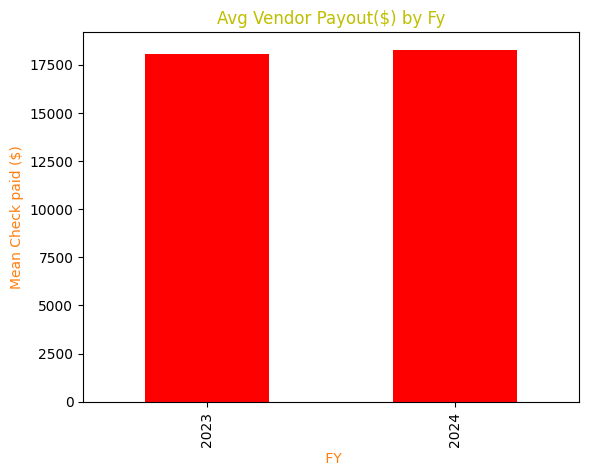

In [35]:
#vizualizing payout by fm/$
df.groupby('fy')['chksubtot'].mean().plot(kind='bar',color= 'r')
plt.title("Avg Vendor Payout($) by Fy", color= 'y')
plt.xlabel(" FY",color= 'C1')
plt.ylabel("Mean Check paid ($)", color= 'C1')
plt.show()

### Evaluation( Data Presentation/Validation--how to present data to stakeholder)

In [36]:
# export for excel data profile
file_name = "temp_staff_contract.xlsx"
with pd.ExcelWriter(file_name) as writer:
    # writing to the 'Employee' sheet
    temp_staff_contract.to_excel(writer, sheet_name='temp_staff_contract', index=False)



### Deployment( Visualization & Presentation)